In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("Utilities.csv")
df.head()

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        22 non-null     object 
 1   Fixed_charge   22 non-null     float64
 2   RoR            22 non-null     float64
 3   Cost           22 non-null     int64  
 4   Load_factor    22 non-null     float64
 5   Demand_growth  22 non-null     float64
 6   Sales          22 non-null     int64  
 7   Nuclear        22 non-null     float64
 8   Fuel_Cost      22 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.7+ KB


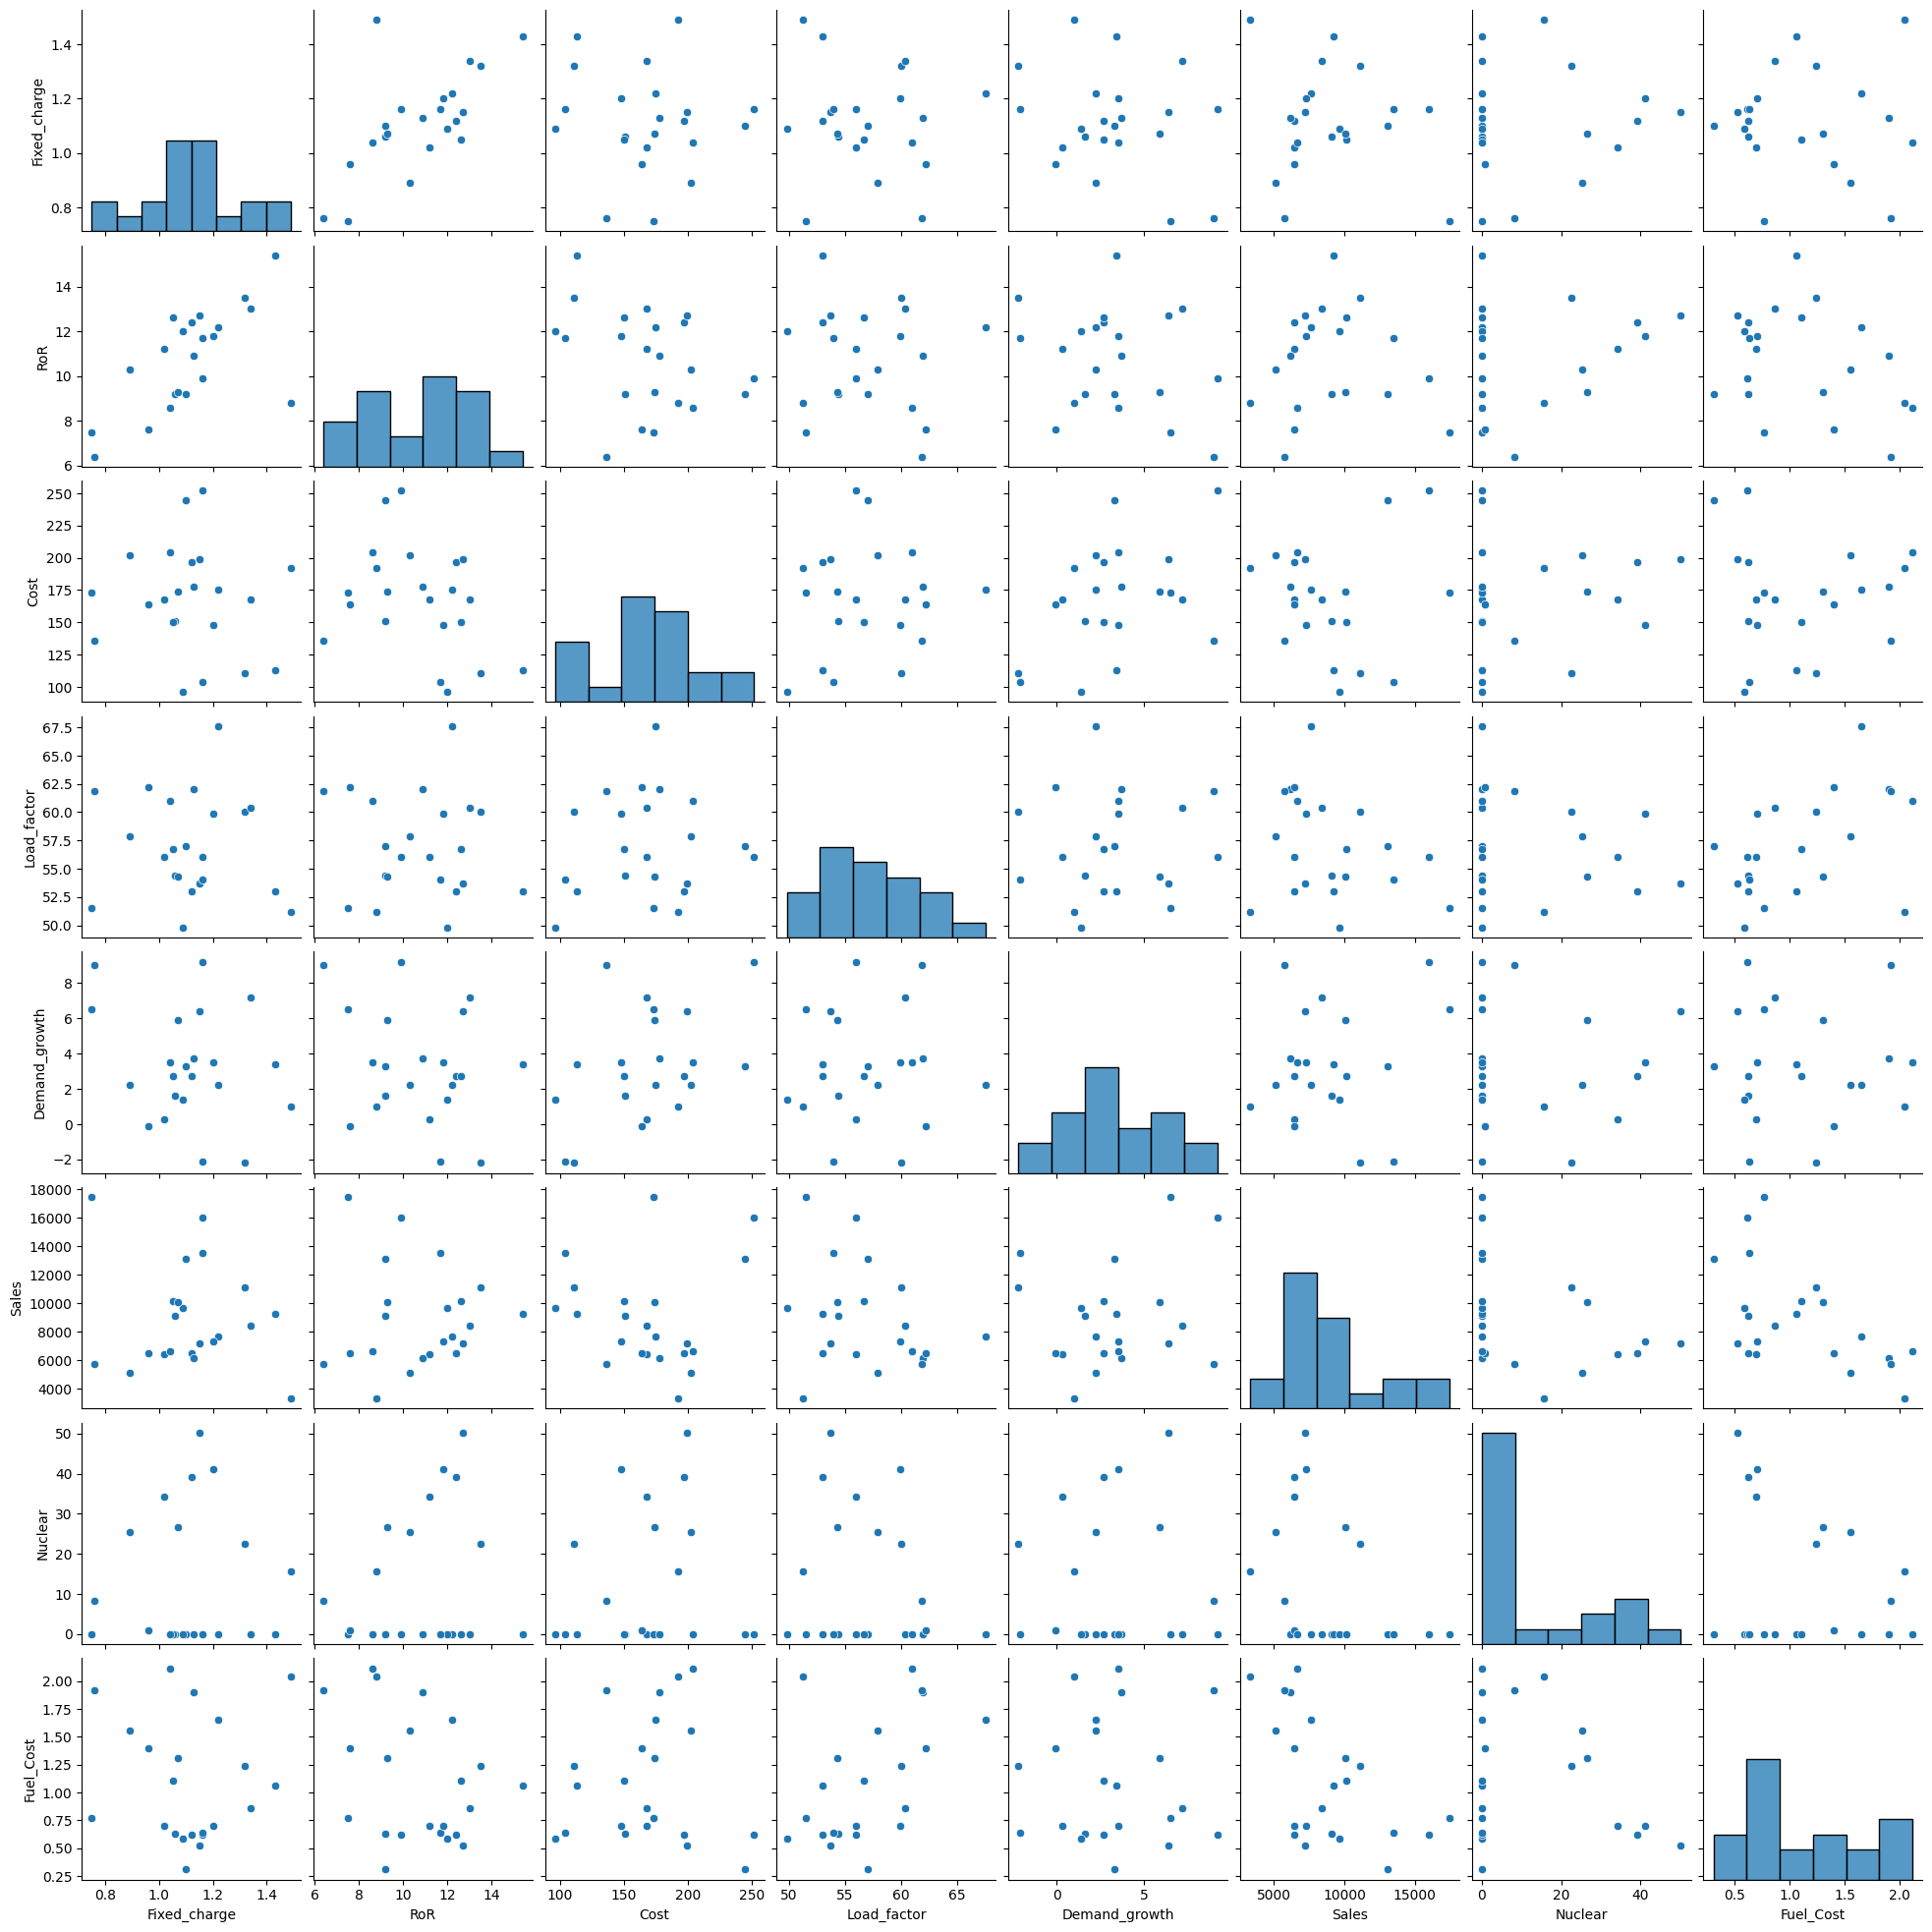

In [4]:
# Visualize all feature dimensions
sns.pairplot(df.drop('Company', axis=1))
plt.show()

In [5]:
# Preprocess the data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df.drop('Company', axis=1))

In [6]:
# Determine the optimal number of clusters using the Elbow Method
wcss = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df_scaled)
    wcss.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

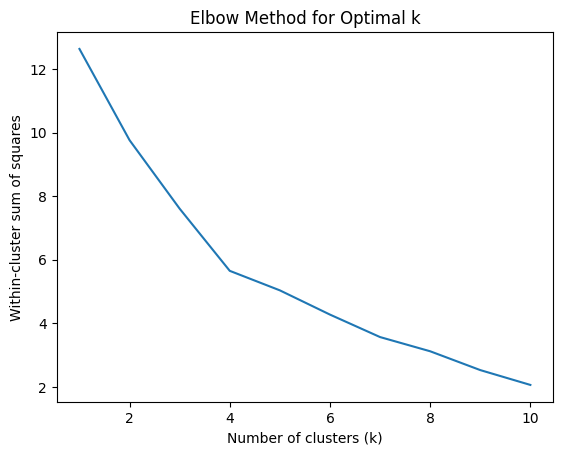

In [7]:
# Plot the Elbow Method graph
plt.plot(k_rng, wcss)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares')
plt.title('Elbow Method for Optimal k')
plt.show()

In [8]:
# Perform K-Means clustering with the optimal number of clusters
k = 4
km = KMeans(n_clusters=k)
y_predicted = km.fit_predict(df_scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [9]:
# Add the cluster labels to the original dataframe
df['Cluster'] = y_predicted

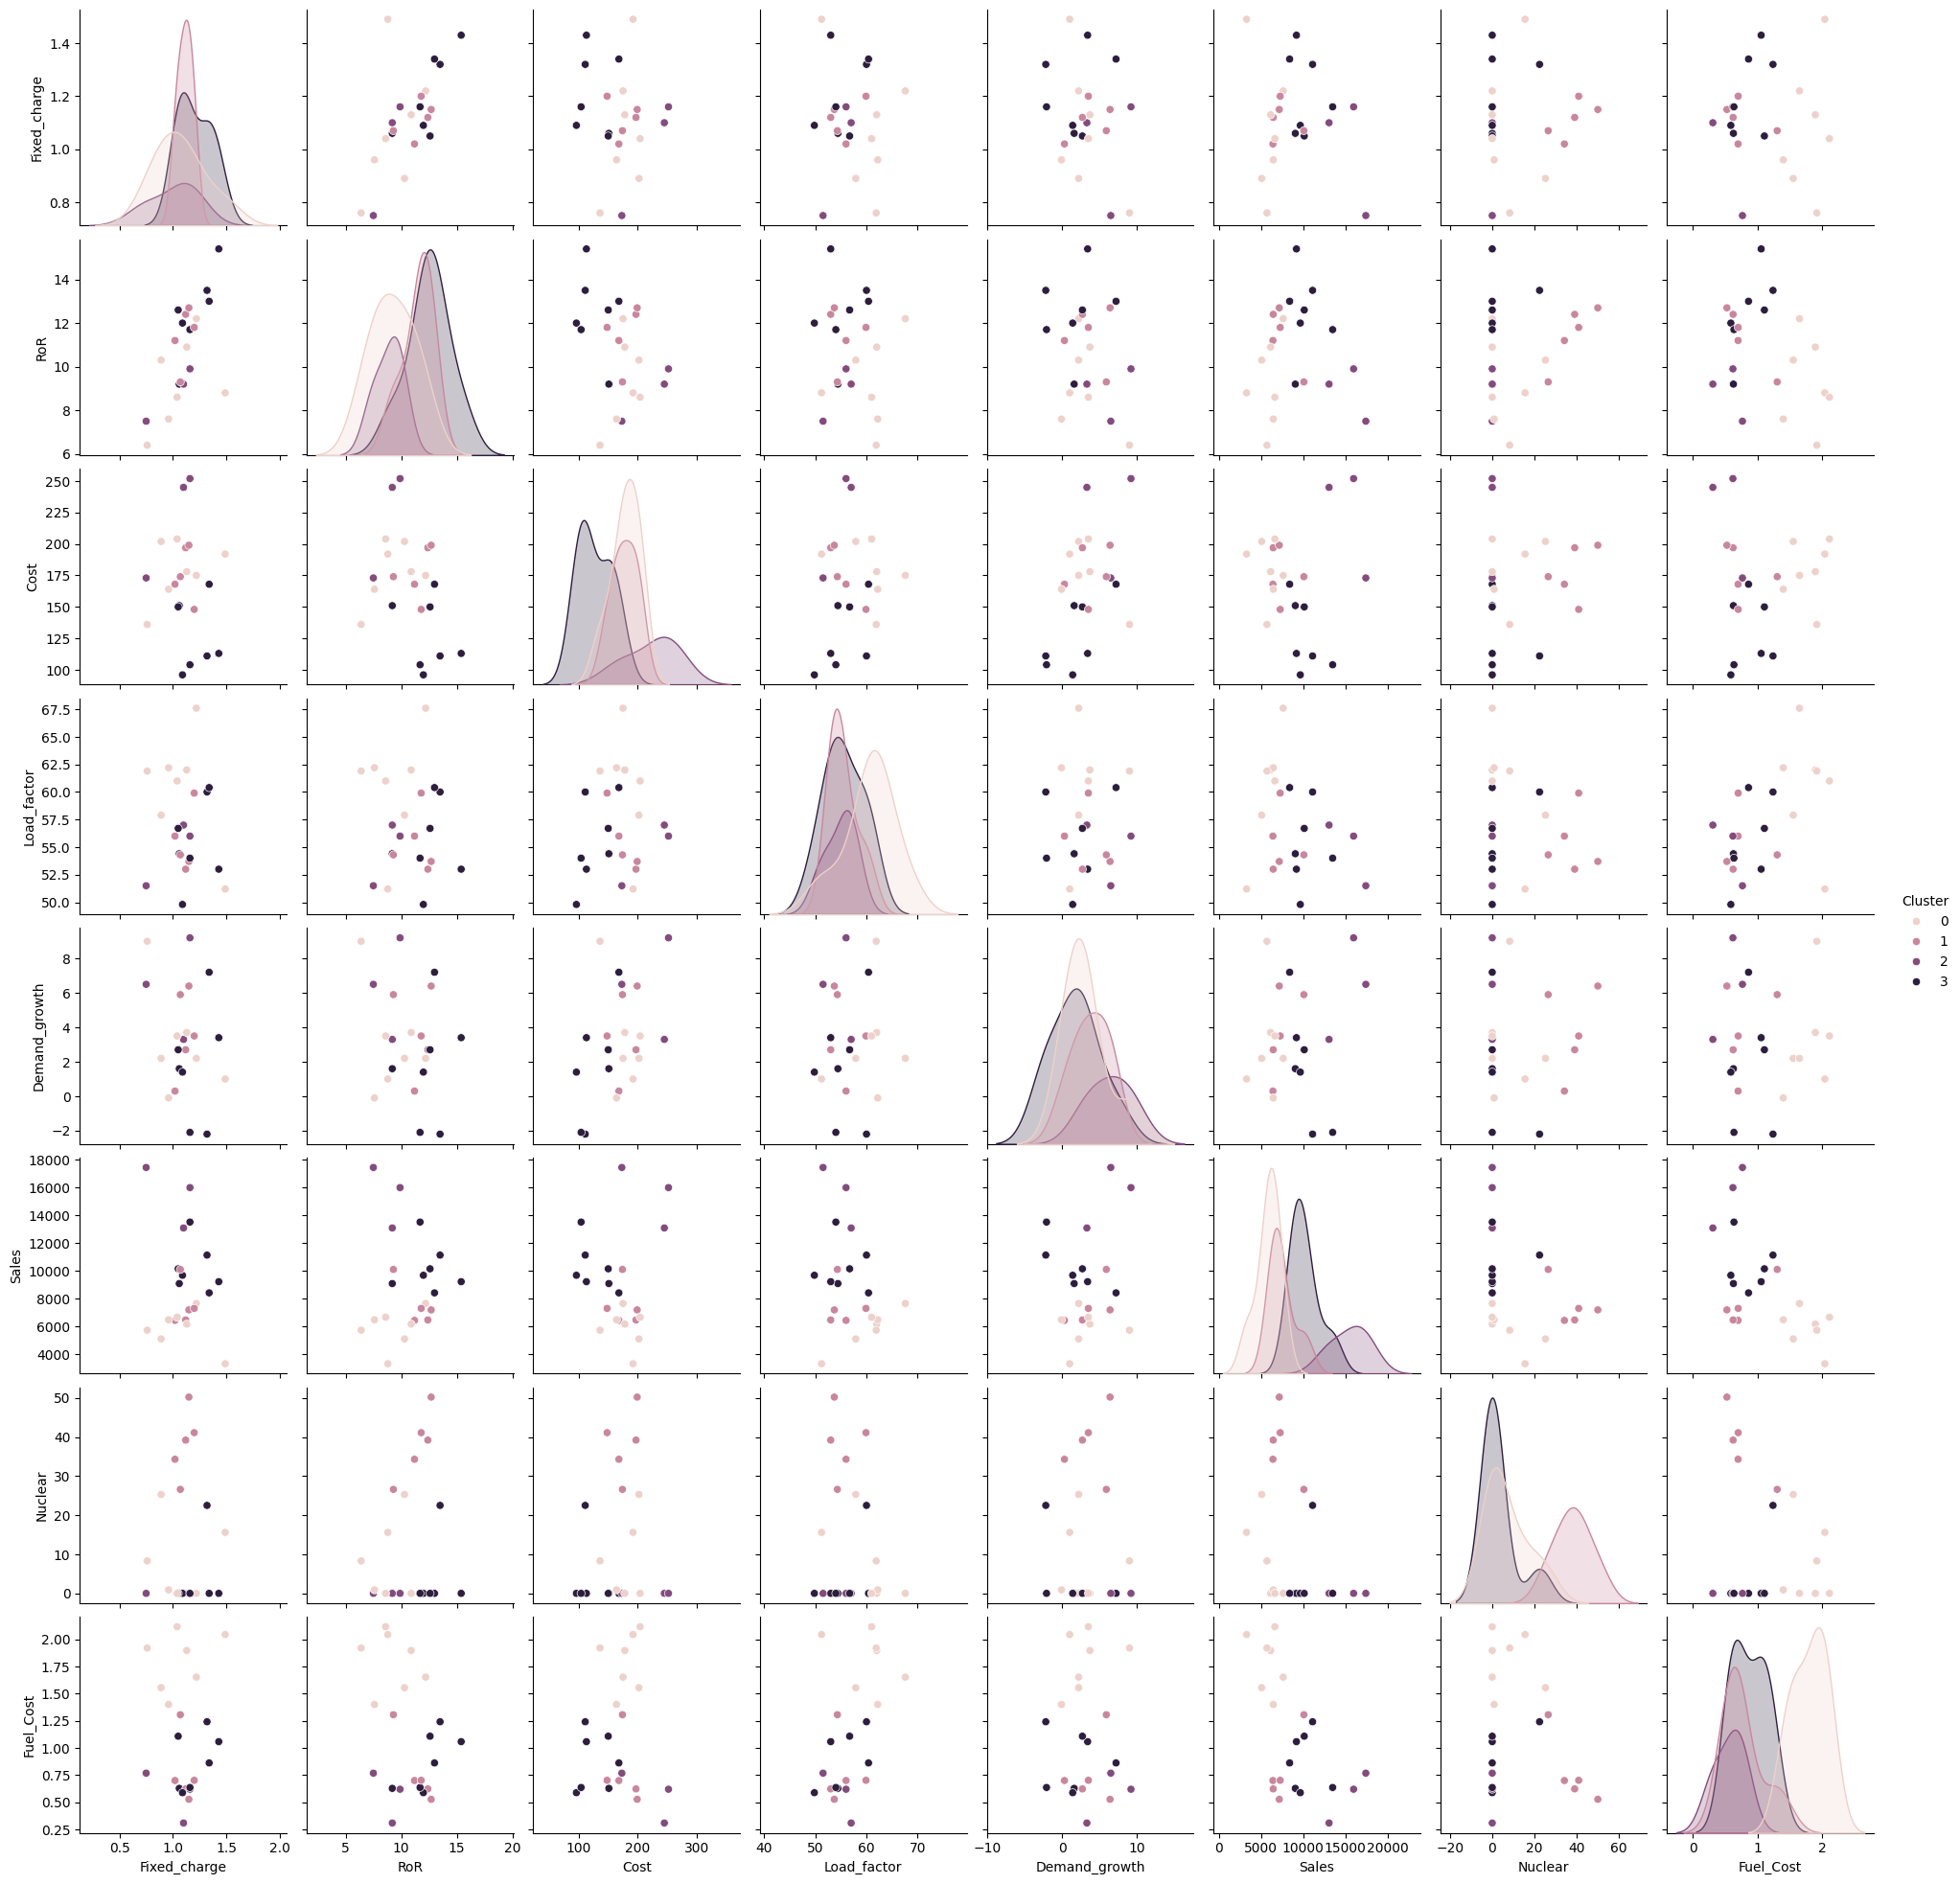

In [10]:
sns.pairplot(df, hue='Cluster')
plt.show()